# 02 — Analyse en composantes principales (ACP)

Le notebook agrège les métriques d'**un seul corpus**, prépare les variables
numériques, impute les valeurs manquantes, standardise les variables puis réalise
une ACP. Les résultats sont écrits dans `analysis/<corpus>/pca/`.


## 1. Configuration


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from metric_registry import get_dataset
from pipeline_utils import detect_project_dir, aggregate_metrics, prepare_numeric_features

PROJECT_DIR = detect_project_dir()
DATASET = "Mirabelle"  # "Mirabelle", "Nowledgeable" ou "Progsnap2"
JOIN_MODE = "outer"
IMPUTATION = "median"  # "median", "mean" ou "drop_rows"
MIN_NON_NULL_FEATURES = 2
DROP_FEATURES = []
RANDOM_STATE = 42  # conservé pour homogénéité ; PCA sklearn est déterministe ici

SPEC = get_dataset(DATASET)
CSV_DIR = SPEC.csv_dir(PROJECT_DIR)
ANALYSIS_DIR = SPEC.analysis_dir(PROJECT_DIR) / "pca"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
print("Corpus  :", DATASET)
print("CSV     :", CSV_DIR)
print("Analyse :", ANALYSIS_DIR)


Corpus  : Nowledgeable
CSV     : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine nettoyée\Chaine_nettoyee\csv\Nowledgeable
Analyse : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine nettoyée\Chaine_nettoyee\analysis\Nowledgeable\pca


## 2. Agrégation et nettoyage


In [9]:
features, inventory_df = aggregate_metrics(CSV_DIR, join_mode=JOIN_MODE)
display(inventory_df)

X_raw, usable_cols, removed_df = prepare_numeric_features(
    features,
    drop_features=DROP_FEATURES,
    min_non_null_features=MIN_NON_NULL_FEATURES,
)
if len(usable_cols) < 2:
    raise ValueError("Il faut au moins deux variables numériques non constantes pour une ACP.")
if not removed_df.empty:
    display(removed_df)

missing = X_raw[usable_cols].isna().mean().mul(100).sort_values(ascending=False)
display(missing.rename("pct_manquant").to_frame())


,fichier,statut,raison,lignes,variables
0,attempts_to_first_success.csv,chargé,,23,AttemptsToFirstSuccess
1,code_change_magnitude.csv,chargé,,29,CodeChangeMagnitude
2,error_quotient.csv,chargé,,28,ErrorQuotient
3,exercise_coverage.csv,chargé,,30,ExerciseCoverage
4,first_attempt_success_rate.csv,chargé,,30,FirstAttemptSuccessRate
5,function_coverage.csv,chargé,,30,FunctionCoverage
6,max_unchanged_code_attempts.csv,chargé,,30,MaxUnchangedCodeAttempts
7,productive_transition_rate.csv,chargé,,29,ProductiveTransitionRate
8,red.csv,chargé,,28,RED
9,score_progression.csv,chargé,,30,ScoreProgression


,pct_manquant
TestPassRate,26.666667
TimeToFirstSuccess,23.333333
AttemptsToFirstSuccess,23.333333
ErrorQuotient,6.666667
RED,6.666667
ProductiveTransitionRate,3.333333
CodeChangeMagnitude,3.333333
MaxUnchangedCodeAttempts,0.000000
FunctionCoverage,0.000000
FirstAttemptSuccessRate,0.000000


## 3. Imputation et standardisation


In [10]:
subject_ids = X_raw["SubjectID"].astype(str).reset_index(drop=True)
X_values = X_raw[usable_cols].copy()

if IMPUTATION == "drop_rows":
    keep = X_values.notna().all(axis=1)
    X_values = X_values.loc[keep].reset_index(drop=True)
    subject_ids = subject_ids.loc[keep].reset_index(drop=True)
elif IMPUTATION in {"median", "mean"}:
    imputer = SimpleImputer(strategy=IMPUTATION)
    X_values = pd.DataFrame(imputer.fit_transform(X_values), columns=usable_cols)
else:
    raise ValueError("IMPUTATION doit valoir 'median', 'mean' ou 'drop_rows'.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

features_for_pca = pd.concat([subject_ids.rename("SubjectID"), X_values], axis=1)
features_for_pca.to_csv(ANALYSIS_DIR / "features_for_pca.csv", index=False)
print(f"{len(subject_ids)} étudiant(s), {len(usable_cols)} variable(s).")


30 étudiant(s), 15 variable(s).


## 4. ACP et fichiers de résultats


In [11]:
pca = PCA()
scores = pca.fit_transform(X_scaled)
component_names = [f"PC{i+1}" for i in range(scores.shape[1])]

explained_df = pd.DataFrame({
    "component": component_names,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_pct": pca.explained_variance_ratio_ * 100,
    "cumulative_variance_pct": np.cumsum(pca.explained_variance_ratio_) * 100,
})

scores_df = pd.DataFrame(scores, columns=component_names)
scores_df.insert(0, "SubjectID", subject_ids.values)

# Les loadings ci-dessous sont les corrélations variable-composante pour des
# données standardisées : composantes * sqrt(valeurs propres).
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=component_names)
loadings_df.insert(0, "variable", usable_cols)

explained_df.to_csv(ANALYSIS_DIR / "explained_variance.csv", index=False)
scores_df.to_csv(ANALYSIS_DIR / "pca_scores.csv", index=False)
loadings_df.to_csv(ANALYSIS_DIR / "pca_loadings.csv", index=False)

display(explained_df.head(10))


,component,explained_variance_ratio,explained_variance_pct,cumulative_variance_pct
0,PC1,0.253445,25.344510,25.344510
1,PC2,0.194515,19.451534,44.796044
2,PC3,0.140064,14.006363,58.802407
3,PC4,0.115033,11.503286,70.305694
4,PC5,0.082605,8.260476,78.566169
5,PC6,0.053988,5.398776,83.964945
6,PC7,0.044030,4.402998,88.367943
7,PC8,0.039560,3.955999,92.323943
8,PC9,0.022376,2.237591,94.561533
9,PC10,0.017383,1.738279,96.299812


## 5. Variance expliquée


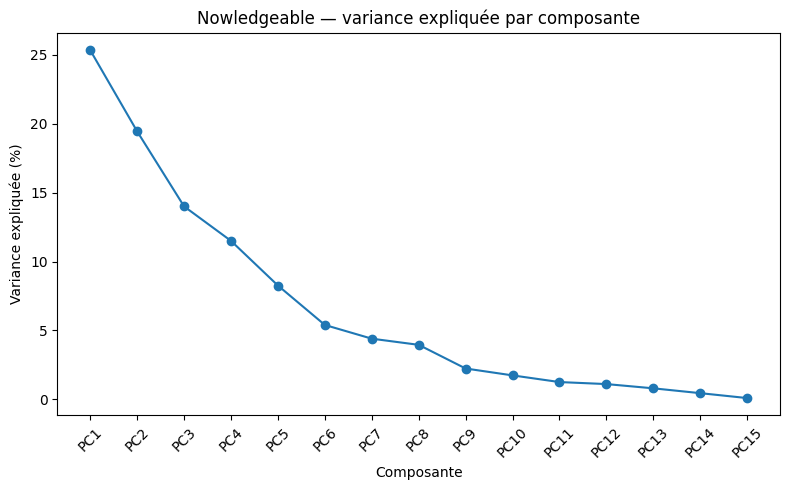

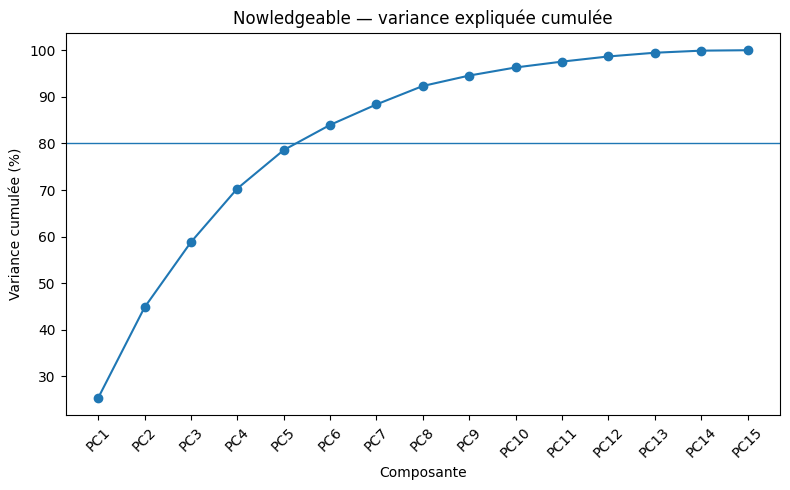

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(explained_df["component"], explained_df["explained_variance_pct"], marker="o")
plt.xlabel("Composante")
plt.ylabel("Variance expliquée (%)")
plt.title(f"{DATASET} — variance expliquée par composante")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(explained_df["component"], explained_df["cumulative_variance_pct"], marker="o")
plt.axhline(80, linewidth=1)
plt.xlabel("Composante")
plt.ylabel("Variance cumulée (%)")
plt.title(f"{DATASET} — variance expliquée cumulée")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Projection et contributions principales


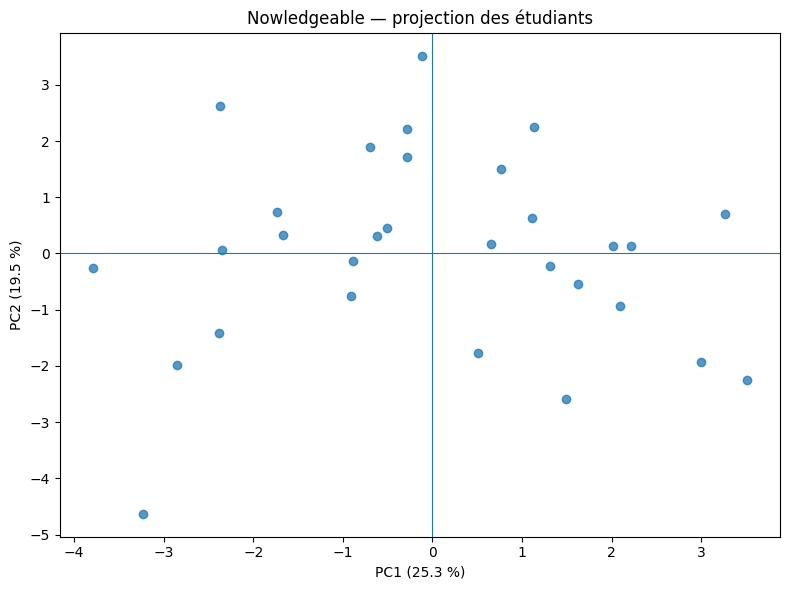


Variables les plus liées à PC1


,variable,PC1
3,ExerciseCoverage,0.936849
5,FunctionCoverage,0.922714
4,FirstAttemptSuccessRate,0.738624
9,ScoreProgression,0.624110
7,ProductiveTransitionRate,0.591111
11,TestPassRate,0.560325
6,MaxUnchangedCodeAttempts,0.471744
8,RED,-0.366902
2,ErrorQuotient,-0.311940
13,TotalTestCount,0.252296



Variables les plus liées à PC2


,variable,PC2
8,RED,0.722375
2,ErrorQuotient,0.657913
10,SessionCount,0.633184
1,CodeChangeMagnitude,-0.584792
12,TimeToFirstSuccess,0.567990
0,AttemptsToFirstSuccess,0.548526
9,ScoreProgression,0.547601
11,TestPassRate,0.412735
4,FirstAttemptSuccessRate,-0.293628
6,MaxUnchangedCodeAttempts,0.271390



Variables les plus liées à PC3


,variable,PC3
0,AttemptsToFirstSuccess,0.687286
13,TotalTestCount,0.638122
2,ErrorQuotient,-0.580243
14,UnchangedRerunRatio,-0.523834
12,TimeToFirstSuccess,0.506629
8,RED,-0.418211
9,ScoreProgression,0.291841
4,FirstAttemptSuccessRate,-0.236597
10,SessionCount,-0.224763
11,TestPassRate,-0.201250



Variables les plus liées à PC4


,variable,PC4
6,MaxUnchangedCodeAttempts,0.687769
14,UnchangedRerunRatio,0.587991
12,TimeToFirstSuccess,0.483537
7,ProductiveTransitionRate,-0.462236
0,AttemptsToFirstSuccess,0.373123
4,FirstAttemptSuccessRate,0.356852
13,TotalTestCount,-0.352826
1,CodeChangeMagnitude,0.211819
9,ScoreProgression,-0.196872
11,TestPassRate,-0.131674



Variables les plus liées à PC5


,variable,PC5
1,CodeChangeMagnitude,0.731111
13,TotalTestCount,-0.471098
14,UnchangedRerunRatio,-0.396556
11,TestPassRate,-0.293641
12,TimeToFirstSuccess,0.263070
9,ScoreProgression,0.252469
5,FunctionCoverage,0.192196
8,RED,0.164060
6,MaxUnchangedCodeAttempts,-0.161111
7,ProductiveTransitionRate,0.158864


In [13]:
if len(component_names) >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.75)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel(f"PC1 ({explained_df.loc[0, 'explained_variance_pct']:.1f} %)")
    plt.ylabel(f"PC2 ({explained_df.loc[1, 'explained_variance_pct']:.1f} %)")
    plt.title(f"{DATASET} — projection des étudiants")
    plt.tight_layout()
    plt.show()

for pc in component_names[:min(5, len(component_names))]:
    tmp = loadings_df[["variable", pc]].copy()
    tmp["abs_loading"] = tmp[pc].abs()
    print()
    print(f"Variables les plus liées à {pc}")
    display(tmp.sort_values("abs_loading", ascending=False).head(10).drop(columns="abs_loading"))


## 7. Matrice de corrélation


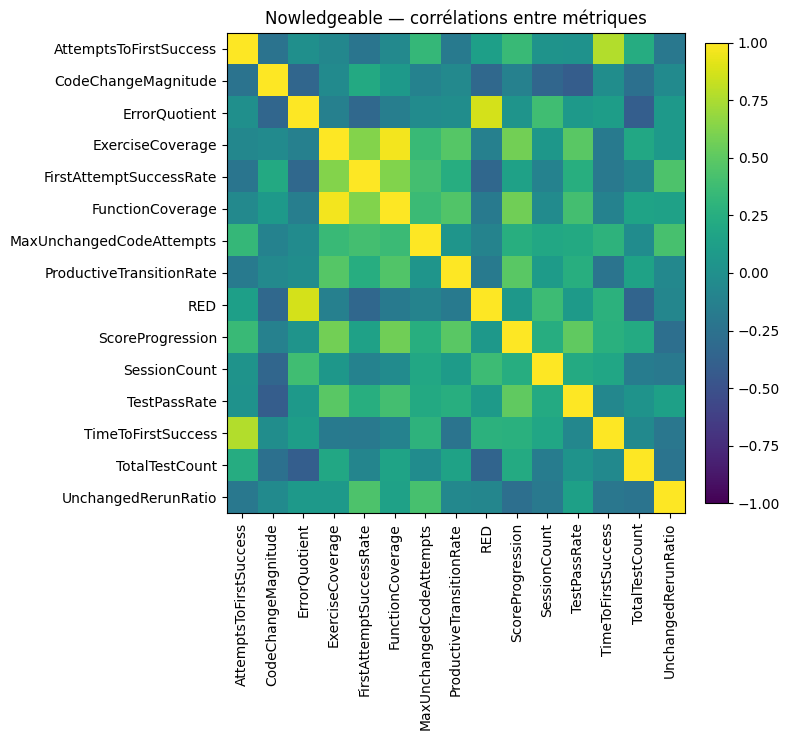

In [14]:
corr = features_for_pca[usable_cols].corr()
plt.figure(figsize=(max(8, 0.5 * len(usable_cols)), max(6, 0.5 * len(usable_cols))))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(usable_cols)), usable_cols, rotation=90)
plt.yticks(range(len(usable_cols)), usable_cols)
plt.title(f"{DATASET} — corrélations entre métriques")
plt.tight_layout()
plt.show()
